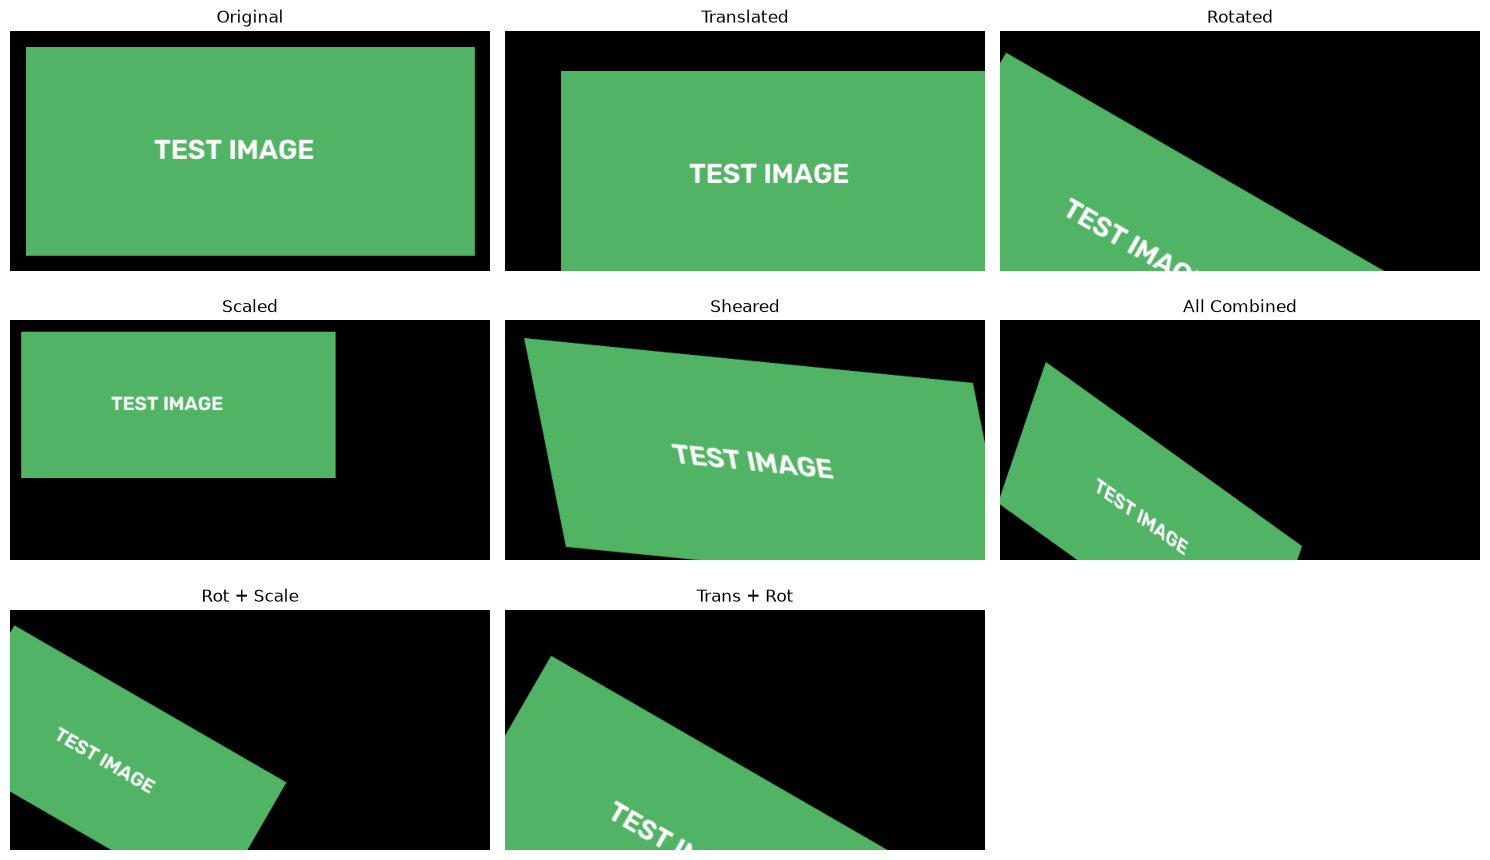

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Load image (Ensure 'cat.jpg' exists in your working directory)
img_loc = "cat.jpg"
img = cv2.imread(img_loc)

# Fallback in case 'cat.jpg' is missing or path is wrong
if img is None:
    print("Warning: Could not find 'cat.jpg'. Generating a placeholder image instead.")
    img = np.zeros((300, 600, 3), dtype=np.uint8)
    cv2.rectangle(img, (20, 20), (580, 280), (100, 180, 80), -1)
    cv2.putText(img, "TEST IMAGE", (180, 160), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_h, img_w = img.shape[:2]

# 2. Pre-defined Transformation Parameters
x_shift, y_shift = 50.0, 30.0
rot_deg = 30.0
scale_x, scale_y = 0.7, 0.7
shear_x, shear_y = 0.2, 0.1

# 3. Build Transformation Matrices
# --- Translation ---
trans_mat = np.array([
    [1.0, 0.0, x_shift],
    [0.0, 1.0, y_shift],
    [0.0, 0.0, 1.0]
], dtype=np.float32)
trans_img = cv2.warpAffine(img, trans_mat[:2, :], (img_w, img_h))

# --- Rotation ---
rads = math.radians(rot_deg)
rot_mat = np.array([
    [math.cos(rads), -math.sin(rads), 0.0],
    [math.sin(rads),  math.cos(rads), 0.0],
    [0.0, 0.0, 1.0]
], dtype=np.float32)
rot_img = cv2.warpAffine(img, rot_mat[:2, :], (img_w, img_h))

# --- Scaling ---
scl_mat = np.array([
    [scale_x, 0.0, 0.0],
    [0.0, scale_y, 0.0],
    [0.0, 0.0, 1.0]
], dtype=np.float32)
scl_img = cv2.warpAffine(img, scl_mat[:2, :], (img_w, img_h))

# --- Shearing ---
shr_mat = np.array([
    [1.0, shear_x, 0.0],
    [shear_y, 1.0, 0.0],
    [0.0, 0.0, 1.0]
], dtype=np.float32)
shr_img = cv2.warpAffine(img, shr_mat[:2, :], (img_w, img_h))

# --- Combined Transformations ---
comb_mat = trans_mat @ rot_mat @ scl_mat @ shr_mat
comb_img = cv2.warpAffine(img, comb_mat[:2, :], (img_w, img_h))

rot_scl_mat = rot_mat @ scl_mat
rot_scl_img = cv2.warpAffine(img, rot_scl_mat[:2, :], (img_w, img_h))

trans_rot_mat = trans_mat @ rot_mat
trans_rot_img = cv2.warpAffine(img, trans_rot_mat[:2, :], (img_w, img_h))

# 4. Save Individual Output Images
cv2.imwrite("out_translated.jpg", trans_img)
cv2.imwrite("out_rotated.jpg", rot_img)
cv2.imwrite("out_scaled.jpg", scl_img)
cv2.imwrite("out_sheared.jpg", shr_img)
cv2.imwrite("out_combined_all.jpg", comb_img)
cv2.imwrite("out_rot_scale.jpg", rot_scl_img)
cv2.imwrite("out_trans_rot.jpg", trans_rot_img)

# 5. Display 3x3 Grid and Save Figure
plt.figure(figsize=(15, 9))

plt.subplot(3, 3, 1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(cv2.cvtColor(trans_img, cv2.COLOR_BGR2RGB))
plt.title("Translated")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(cv2.cvtColor(rot_img, cv2.COLOR_BGR2RGB))
plt.title("Rotated")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(cv2.cvtColor(scl_img, cv2.COLOR_BGR2RGB))
plt.title("Scaled")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(cv2.cvtColor(shr_img, cv2.COLOR_BGR2RGB))
plt.title("Sheared")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(cv2.cvtColor(comb_img, cv2.COLOR_BGR2RGB))
plt.title("All Combined")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(cv2.cvtColor(rot_scl_img, cv2.COLOR_BGR2RGB))
plt.title("Rot + Scale")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.imshow(cv2.cvtColor(trans_rot_img, cv2.COLOR_BGR2RGB))
plt.title("Trans + Rot")
plt.axis("off")

plt.tight_layout()
plt.savefig("sample_output_grid.png", dpi=300, bbox_inches='tight')
plt.show()